In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import Dataset, DataLoader

import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import resnet18

In [28]:
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cuda


In [29]:
class CarlaDataset(Dataset):

    def __init__(self, image_dir, csv_file, transform=None, label_col="has_pedestrian"):
        self.image_dir = image_dir
        self.labels = pd.read_csv(csv_file)
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        frame = int(row["frame"])

        image_path = os.path.join(
            self.image_dir,
            f"{frame:06d}.jpg"
        )

        image = Image.open(image_path).convert("RGB")

        label = float(row[self.label_col])

        if self.transform:
            image = self.transform(image)

        return image, label

In [30]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [31]:
id_dir = "data/test/rgb-front"
id_labels = "data/test/labels.csv"

test_dataset = CarlaDataset(
    id_dir,
    id_labels,
    transform=transform,
    label_col="has_pedestrian"   # change per model
)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [32]:
ped_model = resnet18(weights=None)
ped_model.fc = nn.Linear(ped_model.fc.in_features, 1)

ped_model.load_state_dict(torch.load("pedestrian_model.pth", map_location=device))

ped_model = ped_model.to(device)
ped_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [33]:
def get_predictions(model, loader):

    probs_list = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)

            outputs = model(images).squeeze()

            probs = torch.sigmoid(outputs)

            probs_list.extend(probs.cpu().numpy())
            labels_list.extend(labels.numpy())

    return np.array(probs_list), np.array(labels_list)

In [34]:
def compute_ece(probs, labels, n_bins=10):

    probs = np.array(probs)
    labels = np.array(labels).astype(int)

    preds = (probs >= 0.5).astype(int)

    bins = np.linspace(0, 1, n_bins + 1)

    ece = 0.0

    for i in range(n_bins):

        lower, upper = bins[i], bins[i+1]

        if i == n_bins - 1:
            mask = (probs >= lower) & (probs <= upper)
        else:
            mask = (probs >= lower) & (probs < upper)

        if np.sum(mask) == 0:
            continue

        conf = np.mean(probs[mask])
        acc = np.mean(preds[mask] == labels[mask])

        weight = len(probs[mask]) / len(probs)

        ece += weight * abs(conf - acc)

    return ece

In [35]:
def reliability_diagram(probs, labels, title, n_bins=10):

    probs = np.array(probs)
    labels = np.array(labels).astype(int)
    preds = (probs >= 0.5).astype(int)

    bins = np.linspace(0, 1, n_bins + 1)

    confidences = []
    accuracies = []

    for i in range(n_bins):

        lower, upper = bins[i], bins[i+1]

        if i == n_bins - 1:
            mask = (probs >= lower) & (probs <= upper)
        else:
            mask = (probs >= lower) & (probs < upper)

        if np.sum(mask) == 0:
            continue

        confidences.append(np.mean(probs[mask]))
        accuracies.append(np.mean(preds[mask] == labels[mask]))

    plt.figure(figsize=(6,6))

    plt.plot([0,1], [0,1], "--", label="Perfect")

    plt.plot(confidences, accuracies, marker="o")

    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.grid()
    plt.legend()
    plt.show()

In [36]:
import numpy as np

def compute_ece(probs, labels, n_bins=10):

    probs = np.array(probs)
    labels = np.array(labels)

    preds = (probs >= 0.5).astype(int)
    labels = labels.astype(int)

    bins = np.linspace(0, 1, n_bins + 1)

    ece = 0.0

    for i in range(n_bins):

        # bin range
        lower, upper = bins[i], bins[i + 1]

        # include last bin edge properly
        if i == n_bins - 1:
            mask = (probs >= lower) & (probs <= upper)
        else:
            mask = (probs >= lower) & (probs < upper)

        if np.sum(mask) == 0:
            continue

        bin_probs = probs[mask]
        bin_preds = preds[mask]
        bin_labels = labels[mask]

        # confidence = mean predicted probability
        confidence = np.mean(bin_probs)

        # accuracy = mean correct predictions
        accuracy = np.mean(bin_preds == bin_labels)

        weight = len(bin_probs) / len(probs)

        ece += weight * abs(confidence - accuracy)

    return ece

In [37]:
def reliability_diagram(probs, labels, title, n_bins=10):

    probs = np.array(probs)
    labels = np.array(labels).astype(int)
    preds = (probs >= 0.5).astype(int)

    bins = np.linspace(0, 1, n_bins + 1)

    confidences = []
    accuracies = []

    for i in range(n_bins):

        lower, upper = bins[i], bins[i+1]

        if i == n_bins - 1:
            mask = (probs >= lower) & (probs <= upper)
        else:
            mask = (probs >= lower) & (probs < upper)

        if np.sum(mask) == 0:
            continue

        confidences.append(np.mean(probs[mask]))
        accuracies.append(np.mean(preds[mask] == labels[mask]))

    plt.figure(figsize=(6,6))

    plt.plot([0,1], [0,1], "--", label="Perfect")

    plt.plot(confidences, accuracies, marker="o")

    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.grid()
    plt.legend()
    plt.show()

ECE: 0.7493558747921554


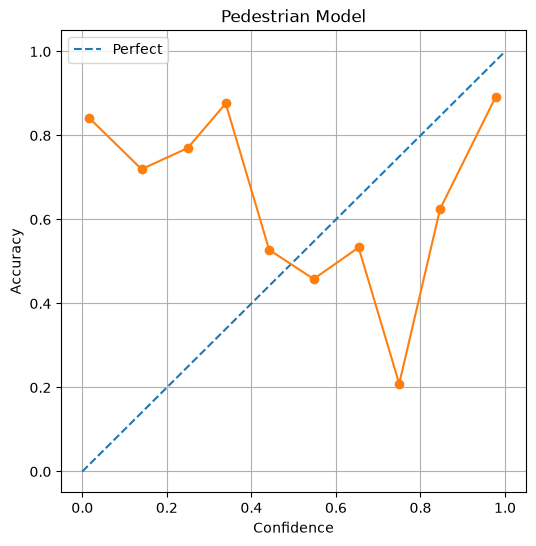

In [38]:
test_dataset = CarlaDataset(
    id_dir,
    id_labels,
    transform=transform,
    label_col="has_pedestrian"
)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

probs, labels = get_predictions(ped_model, test_loader)

print("ECE:", compute_ece(probs, labels))

reliability_diagram(probs, labels, "Pedestrian Model")

In [39]:
vehicle_dataset = CarlaDataset(
    id_dir,
    id_labels,
    transform=transform,
    label_col="has_vehicle"
)

vehicle_loader = DataLoader(vehicle_dataset, batch_size=32, shuffle=False)

In [40]:
vehicle_model = resnet18(weights=None)
vehicle_model.fc = nn.Linear(vehicle_model.fc.in_features, 1)

checkpoint = torch.load("vehicle_model.pth", map_location=device)
vehicle_model.load_state_dict(checkpoint)

vehicle_model = vehicle_model.to(device)
vehicle_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Vehicle ECE: 0.22606049563528766


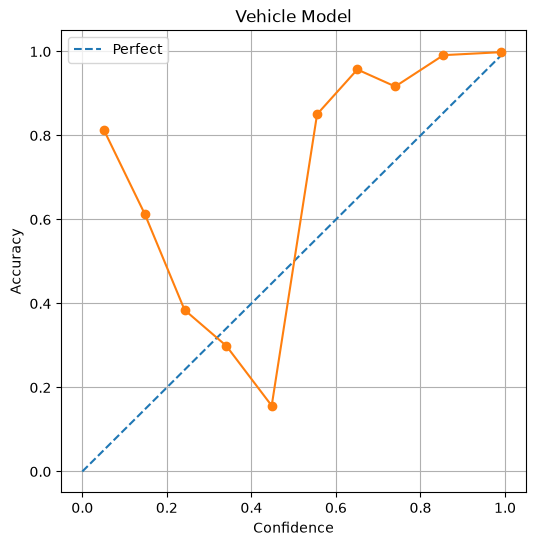

In [41]:
vehicle_probs, vehicle_labels = get_predictions(vehicle_model, vehicle_loader)

print("Vehicle ECE:", compute_ece(vehicle_probs, vehicle_labels))

reliability_diagram(
    vehicle_probs,
    vehicle_labels,
    "Vehicle Model"
)

In [42]:
traffic_dataset = CarlaDataset(
    id_dir,
    id_labels,
    transform=transform,
    label_col="has_traffic_light"
)

traffic_loader = DataLoader(traffic_dataset, batch_size=32, shuffle=False)

In [43]:
traffic_model = resnet18(weights=None)
traffic_model.fc = nn.Linear(traffic_model.fc.in_features, 1)

traffic_checkpoint = torch.load("traffic_light_model.pth", map_location=device)
traffic_model.load_state_dict(traffic_checkpoint)

traffic_model = traffic_model.to(device)
traffic_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Traffic Light ECE: 0.24498577173178399


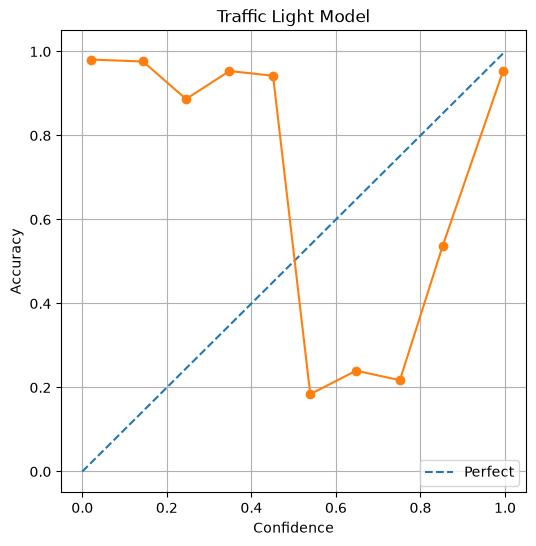

In [44]:
traffic_probs, traffic_labels = get_predictions(traffic_model, traffic_loader)

print("Traffic Light ECE:", compute_ece(traffic_probs, traffic_labels))

reliability_diagram(
    traffic_probs,
    traffic_labels,
    "Traffic Light Model"
)

In [45]:
class ModelWithTemperature(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.0)

    def forward(self, x):
        logits = self.model(x).squeeze()
        return logits / self.temperature

In [46]:
def nll_loss(logits, labels):
    return nn.functional.binary_cross_entropy_with_logits(
        logits,
        labels
    )

In [47]:
def optimize_temperature(model, loader, device):
    model = ModelWithTemperature(model).to(device)

    optimizer = torch.optim.LBFGS([model.temperature], lr=0.01, max_iter=50)

    labels_all = []
    logits_all = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).float()

            logits = model.model(x).squeeze()

            logits_all.append(logits)
            labels_all.append(y)

    logits_all = torch.cat(logits_all)
    labels_all = torch.cat(labels_all)

    def eval():
        optimizer.zero_grad()
        loss = nll_loss(logits_all / model.temperature, labels_all)
        loss.backward()
        return loss

    optimizer.step(eval)

    return model

In [48]:
def get_logits(model, loader):
    logits_list = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            logits = model(images).squeeze()

            logits_list.extend(logits.cpu().numpy())
            labels_list.extend(labels.numpy())

    return np.array(logits_list), np.array(labels_list)

In [49]:
def logits_to_probs(logits, temperature=1.0):
    return 1 / (1 + np.exp(-(logits / temperature)))

In [50]:
ped_logits, ped_labels = get_logits(ped_model, test_loader)
ped_probs = 1 / (1 + np.exp(-ped_logits))

ece_before = compute_ece(ped_probs, ped_labels)
print("ECE before:", ece_before)

ECE before: 0.7493558743492597


In [51]:
ped_model_t = optimize_temperature(ped_model, test_loader, device)

In [52]:
ped_logits_t, _ = get_logits(ped_model_t.model, test_loader)
T = ped_model_t.temperature.item()

ped_probs_t = logits_to_probs(ped_logits_t, temperature=T)

ece_after = compute_ece(ped_probs_t, ped_labels)
print("ECE after:", ece_after)
print("Temperature:", T)

ECE after: 0.7323111937339932
Temperature: 1.2315089702606201


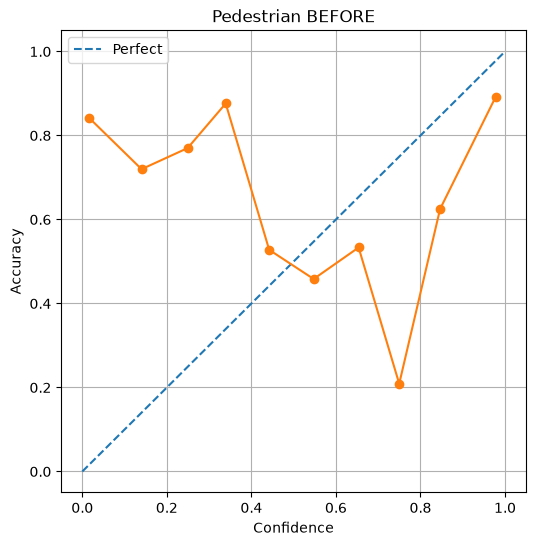

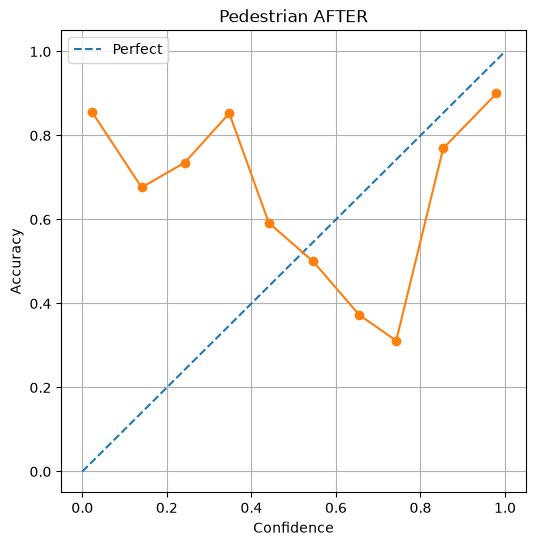

In [53]:
reliability_diagram(ped_probs, ped_labels, "Pedestrian BEFORE")
reliability_diagram(ped_probs_t, ped_labels, "Pedestrian AFTER")

In [54]:
vehicle_logits, vehicle_labels = get_logits(vehicle_model, vehicle_loader)
vehicle_probs = 1 / (1 + np.exp(-vehicle_logits))

ece_vehicle_before = compute_ece(vehicle_probs, vehicle_labels)
print("Vehicle ECE before:", ece_vehicle_before)

Vehicle ECE before: 0.2260604941948421


In [55]:
vehicle_model_t = optimize_temperature(vehicle_model, vehicle_loader, device)
T_vehicle = vehicle_model_t.temperature.item()

print("Vehicle Temperature:", T_vehicle)

Vehicle Temperature: 1.121659278869629


In [56]:
vehicle_logits_t, _ = get_logits(vehicle_model_t.model, vehicle_loader)

vehicle_probs_t = logits_to_probs(vehicle_logits_t, T_vehicle)

ece_vehicle_after = compute_ece(vehicle_probs_t, vehicle_labels)

print("Vehicle ECE after:", ece_vehicle_after)

Vehicle ECE after: 0.22448122237809004


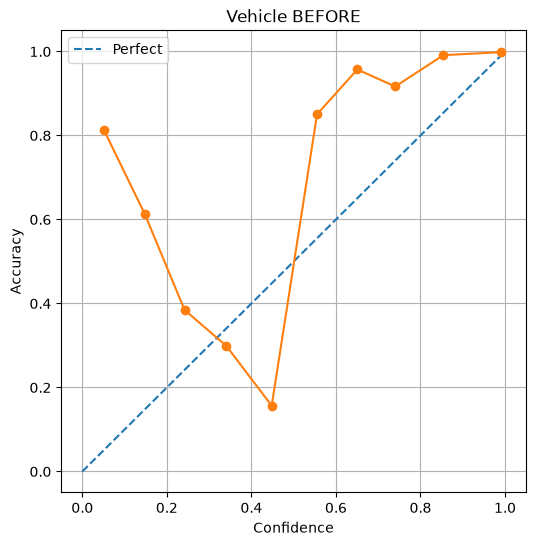

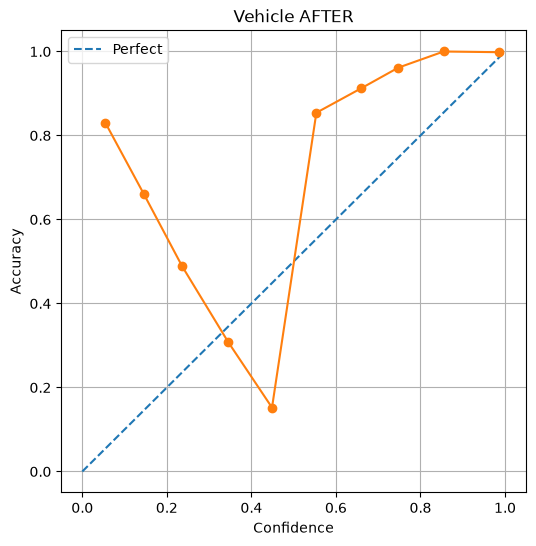

In [57]:
reliability_diagram(vehicle_probs, vehicle_labels, "Vehicle BEFORE")
reliability_diagram(vehicle_probs_t, vehicle_labels, "Vehicle AFTER")

In [58]:
traffic_logits, traffic_labels = get_logits(traffic_model, traffic_loader)
traffic_probs = 1 / (1 + np.exp(-traffic_logits))

ece_traffic_before = compute_ece(traffic_probs, traffic_labels)
print("Traffic ECE before:", ece_traffic_before)

Traffic ECE before: 0.244985770870828


In [59]:
traffic_model_t = optimize_temperature(traffic_model, traffic_loader, device)
T_traffic = traffic_model_t.temperature.item()

print("Traffic Temperature:", T_traffic)

Traffic Temperature: 1.1843456029891968


In [60]:
traffic_logits_t, _ = get_logits(traffic_model_t.model, traffic_loader)

traffic_probs_t = logits_to_probs(traffic_logits_t, T_traffic)

ece_traffic_after = compute_ece(traffic_probs_t, traffic_labels)

print("Traffic ECE after:", ece_traffic_after)

Traffic ECE after: 0.23759827098136563


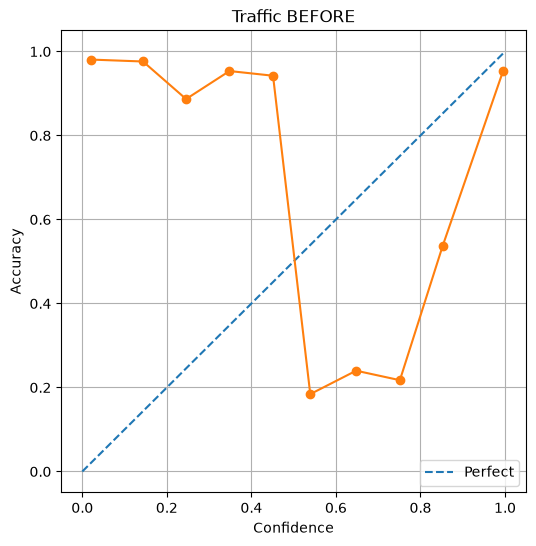

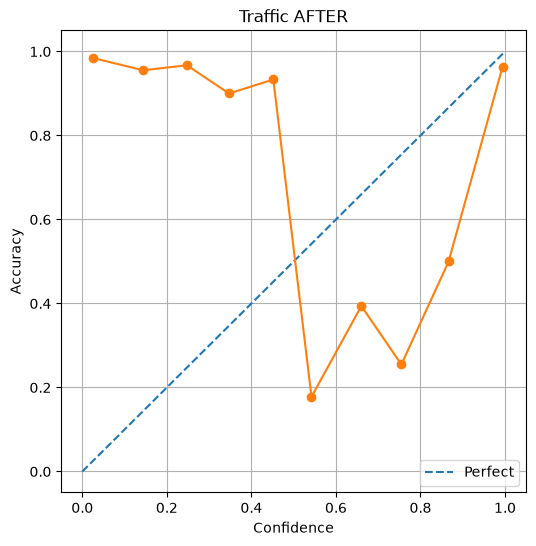

In [61]:
reliability_diagram(traffic_probs, traffic_labels, "Traffic BEFORE")
reliability_diagram(traffic_probs_t, traffic_labels, "Traffic AFTER")

In [62]:
import numpy as np
import torch
import torch.nn.functional as F

def nll_for_temperature(logits, labels, T):
    logits_T = logits / T
    loss = F.binary_cross_entropy_with_logits(
        torch.tensor(logits_T),
        torch.tensor(labels).float()
    )
    return loss.item()

In [63]:
def find_best_temperature(logits, labels, t_min=0.5, t_max=3.0, step=0.1):
    best_T = t_min
    best_nll = float("inf")

    Ts = np.arange(t_min, t_max + step, step)

    for T in Ts:
        nll = nll_for_temperature(logits, labels, T)

        if nll < best_nll:
            best_nll = nll
            best_T = T

    return best_T, best_nll

In [64]:
ped_logits, ped_labels = get_logits(ped_model, test_loader)

# BEFORE
ped_probs_before = torch.sigmoid(torch.tensor(ped_logits)).numpy()
ece_ped_before = compute_ece(ped_probs_before, ped_labels)

# FIND BEST T
best_T_ped, _ = find_best_temperature(ped_logits, ped_labels)

# AFTER
ped_probs_after = logits_to_probs(ped_logits, best_T_ped)
ece_ped_after = compute_ece(ped_probs_after, ped_labels)

print("=== PEDESTRIAN ===")
print("Best T:", best_T_ped)
print("ECE before:", ece_ped_before)
print("ECE after:", ece_ped_after)

=== PEDESTRIAN ===
Best T: 2.9999999999999996
ECE before: 0.7493558730661042
ECE after: 0.6091718979813302


In [65]:
vehicle_logits, vehicle_labels = get_logits(vehicle_model, vehicle_loader)

# BEFORE
vehicle_probs_before = torch.sigmoid(torch.tensor(vehicle_logits)).numpy()
ece_vehicle_before = compute_ece(vehicle_probs_before, vehicle_labels)

# FIND BEST T
best_T_vehicle, _ = find_best_temperature(vehicle_logits, vehicle_labels)

# AFTER
vehicle_probs_after = logits_to_probs(vehicle_logits, best_T_vehicle)
ece_vehicle_after = compute_ece(vehicle_probs_after, vehicle_labels)

print("=== VEHICLE ===")
print("Best T:", best_T_vehicle)
print("ECE before:", ece_vehicle_before)
print("ECE after:", ece_vehicle_after)

=== VEHICLE ===
Best T: 1.4999999999999998
ECE before: 0.22606049563528766
ECE after: 0.2197271390153656


In [66]:
traffic_logits, traffic_labels = get_logits(traffic_model, traffic_loader)

# BEFORE
traffic_probs_before = torch.sigmoid(torch.tensor(traffic_logits)).numpy()
ece_traffic_before = compute_ece(traffic_probs_before, traffic_labels)

# FIND BEST T
best_T_traffic, _ = find_best_temperature(traffic_logits, traffic_labels)

# AFTER
traffic_probs_after = logits_to_probs(traffic_logits, best_T_traffic)
ece_traffic_after = compute_ece(traffic_probs_after, traffic_labels)

print("=== TRAFFIC LIGHT ===")
print("Best T:", best_T_traffic)
print("ECE before:", ece_traffic_before)
print("ECE after:", ece_traffic_after)

=== TRAFFIC LIGHT ===
Best T: 1.8999999999999997
ECE before: 0.24498577149998813
ECE after: 0.20723033433510527


In [67]:
def cost_loss(probs, labels, threshold, cfn=100, cfp=1):
    preds = (probs >= threshold).astype(int)
    labels = labels.astype(int)

    fn = np.sum((preds == 0) & (labels == 1))
    fp = np.sum((preds == 1) & (labels == 0))

    return cfn * fn + cfp * fp, fn, fp

In [68]:
ped_logits, ped_labels = get_logits(ped_model, test_loader)

ped_probs_uncal = 1 / (1 + np.exp(-ped_logits))

In [69]:
ped_probs_cal = logits_to_probs(ped_logits, best_T_ped)

In [70]:
tau_1 = 0.5
tau_star = 0.0099

In [71]:
loss_uncal_05, fn1, fp1 = cost_loss(ped_probs_uncal, ped_labels, tau_1)
loss_uncal_star, fn2, fp2 = cost_loss(ped_probs_uncal, ped_labels, tau_star)

In [72]:
loss_cal_05, fn3, fp3 = cost_loss(ped_probs_cal, ped_labels, tau_1)
loss_cal_star, fn4, fp4 = cost_loss(ped_probs_cal, ped_labels, tau_star)

In [73]:
import pandas as pd

table = pd.DataFrame(
    {
        "τ = 0.5": [loss_uncal_05, loss_cal_05],
        "τ = τ*": [loss_uncal_star, loss_cal_star]
    },
    index=["Uncalibrated", "Calibrated"]
)

print(table)

              τ = 0.5  τ = τ*
Uncalibrated    57201   22938
Calibrated      57201    2894
